#Replikasi Metodologi

Kelompok 5


*   Gafna Al Faatiha Prabowo 	(23/516550/PA/22099)
*   Syafran Abdillah Erdin	 (23/521752/PA/22444)
*   Iqbal Pandu Santoso		 (23/517100/PA/22150)
*   Dzikran Azka Sajidan 	 (23/516665/PA/22110)



## Import Library

In [ ]:
import os
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, matthews_corrcoef
import numpy as np
import warnings

warnings.filterwarnings('ignore')

## Pengumpulan dan Pra-pemrosesan Data

In [ ]:
# PENGUMPULAN & PRA-PEMROSESAN DATA
print("Mengunduh dataset...")
path = kagglehub.dataset_download("sid321axn/heart-statlog-cleveland-hungary-final")
dataset_path = os.path.join(path, "heart_statlog_cleveland_hungary_final.csv")

df = pd.read_csv(dataset_path)
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

continuous_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
categorical_features = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', 'passthrough', categorical_features)
    ])

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else 0.0,
        "Kappa": cohen_kappa_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

Mengunduh dataset...
Using Colab cache for faster access to the 'heart-statlog-cleveland-hungary-final' dataset.


## Pemodelan

In [ ]:
# DEFINISI MODEL & HYPERPARAMETER GRID
# Mendefinisikan estimator dasar untuk Stacking
estimators_for_stacking = [
    ('lr', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('svm', SVC(probability=True, random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]

base_models = {
    "Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Stacking": StackingClassifier(estimators=estimators_for_stacking, final_estimator=LogisticRegression())
}

param_grids = {
    "Logistic Regression": {'classifier__C': [0.01, 0.1, 1, 10], 'classifier__penalty': ['l2']},
    "KNN": {'classifier__n_neighbors': [3, 5, 7, 9, 11], 'classifier__weights': ['uniform', 'distance']},
    "SVM": {'classifier__C': [0.1, 1, 10, 50], 'classifier__kernel': ['linear', 'rbf']},
    "Random Forest": {'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [None, 10, 20], 'classifier__min_samples_split': [2, 5]},
    "Gradient Boosting": {'classifier__learning_rate': [0.01, 0.1, 0.2], 'classifier__n_estimators': [50, 100], 'classifier__max_depth': [3, 4, 5]}
}

results_baseline = []
results_grid = []
results_random = []

## Evaluasi

In [ ]:
# PROSES TRAINING & EVALUASI
print("\nMelatih Model Baseline (Classification)...")
for name, model in base_models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline.named_steps['classifier'], "predict_proba") else None

    metrics = evaluate_model(y_test, y_pred, y_prob)
    metrics['Model'] = name
    metrics['Search Method'] = 'Classification'
    results_baseline.append(metrics)

print("Melakukan Grid Search...")
for name, model in base_models.items():
    if name == "Stacking":
        continue # Sesuai paper, Stacking tidak di-tuning di tahap ini

    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    gs = GridSearchCV(pipeline, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, y_train)

    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:, 1] if hasattr(gs.best_estimator_.named_steps['classifier'], "predict_proba") else None

    metrics = evaluate_model(y_test, y_pred, y_prob)
    metrics['Model'] = name
    metrics['Search Method'] = 'Grid Search'
    metrics['Best Params'] = str(gs.best_params_)
    results_grid.append(metrics)

print("Melakukan Random Search...")
for name, model in base_models.items():
    if name == "Stacking":
        continue # Sesuai paper, Stacking tidak di-tuning di tahap ini

    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    grid = param_grids[name]
    max_kombinasi = np.prod([len(v) for v in grid.values()])
    n_iter = min(10, max_kombinasi)

    rs = RandomizedSearchCV(pipeline, grid, n_iter=n_iter, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
    rs.fit(X_train, y_train)

    y_pred = rs.predict(X_test)
    y_prob = rs.predict_proba(X_test)[:, 1] if hasattr(rs.best_estimator_.named_steps['classifier'], "predict_proba") else None

    metrics = evaluate_model(y_test, y_pred, y_prob)
    metrics['Model'] = name
    metrics['Search Method'] = 'Random Search'
    metrics['Best Params'] = str(rs.best_params_)
    results_random.append(metrics)


Melatih Model Baseline (Classification)...
Melakukan Grid Search...
Melakukan Random Search...


In [ ]:
# MENAMPILKAN TABEL
cols_metrics = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Kappa', 'MCC']
cols_with_params = ['Model', 'Best Params', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Kappa', 'MCC']

df_base = pd.DataFrame(results_baseline)
df_grid = pd.DataFrame(results_grid)
df_random = pd.DataFrame(results_random)

print("\n" + "="*80)
print("Table 1. Performance Evaluation Metrics of Different Classifiers (Baseline)")
print("="*80)
print(df_base[cols_metrics].round(6).to_string(index=False))

print("\n" + "="*80)
print("Table 2. Performance Evaluation Results of Classifiers with Grid Search")
print("="*80)
df_grid['Best Params'] = df_grid['Best Params'].apply(lambda x: x.replace('classifier__', ''))
print(df_grid[cols_with_params].round(6).to_string(index=False))

print("\n" + "="*80)
print("Table 3. Performance Evaluation Metrics of Different Classifiers with Random Search")
print("="*80)
df_random['Best Params'] = df_random['Best Params'].apply(lambda x: x.replace('classifier__', ''))
print(df_random[cols_with_params].round(6).to_string(index=False))


Table 1. Performance Evaluation Metrics of Different Classifiers (Baseline)
              Model  Accuracy  Precision   Recall  F1 Score      AUC    Kappa      MCC
Logistic Regression  0.861345   0.871212 0.877863  0.874525 0.908825 0.719600 0.719626
                KNN  0.857143   0.859259 0.885496  0.872180 0.927338 0.710359 0.710771
                SVM  0.878151   0.875000 0.908397  0.891386 0.929371 0.752741 0.753426
      Random Forest  0.953782   0.947761 0.969466  0.958491 0.969109 0.906373 0.906669
  Gradient Boosting  0.915966   0.917293 0.931298  0.924242 0.959692 0.829915 0.830035
           Stacking  0.957983   0.948148 0.977099  0.962406 0.968824 0.914811 0.915343

Table 2. Performance Evaluation Results of Classifiers with Grid Search
              Model                                                      Best Params  Accuracy  Precision   Recall  F1 Score      AUC    Kappa      MCC
Logistic Regression                                        {'C': 1, 'penalty': 'l2'}  0.8


Menyiapkan grafik perbandingan...


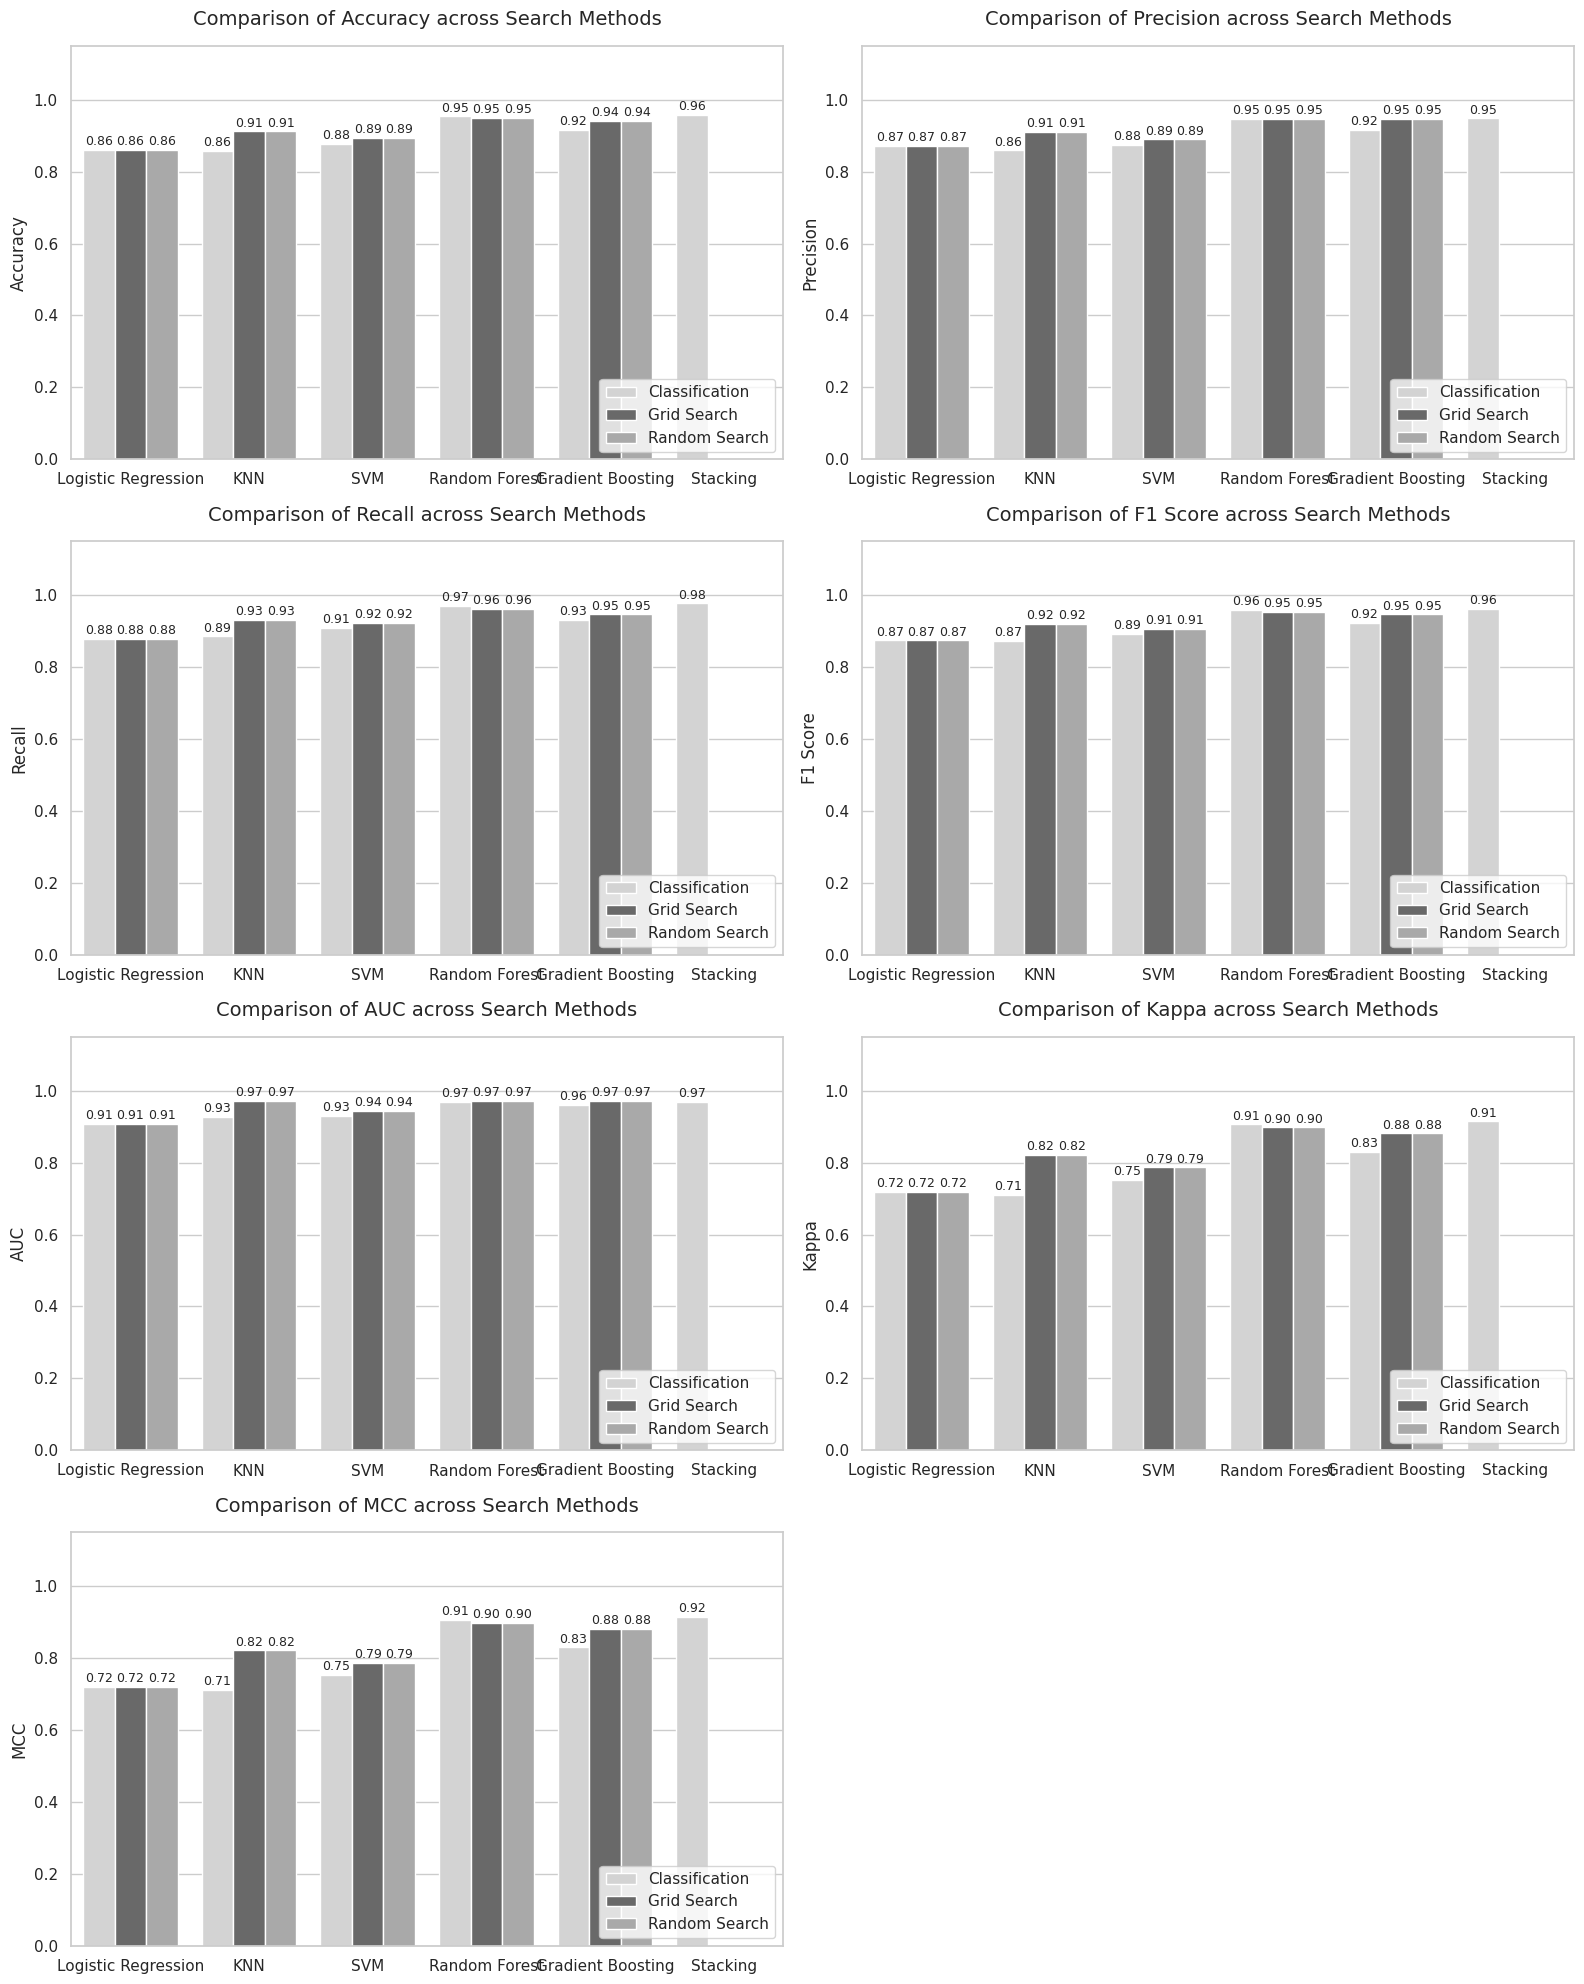

In [ ]:
# VISUALISASI GRAFIK PERBANDINGAN
print("\nMenyiapkan grafik perbandingan...")
df_all = pd.concat([df_base, df_grid, df_random], ignore_index=True)

sns.set_theme(style="whitegrid")
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Kappa', 'MCC']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

palette = {'Classification': '#d3d3d3', 'Grid Search': '#696969', 'Random Search': '#a9a9a9'}

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Model', y=metric, hue='Search Method', data=df_all, ax=axes[i], palette=palette)
    axes[i].set_title(f'Comparison of {metric} across Search Methods', fontsize=14, pad=15)
    axes[i].set_ylim(0, 1.15)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='', loc='lower right')

    for p in axes[i].patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            axes[i].annotate(format(height, '.2f'),
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='center',
                             xytext=(0, 6),
                             textcoords='offset points',
                             fontsize=9)

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()